In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# 1. Load the dataset using the relative path from part_a/ to data/
# '../' moves up to the root, then enters the data folder
df = pd.read_csv('../data/q2_customers.csv')

# 2. Display basic info to confirm loading
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

# 3. Scale all features using StandardScaler
# We do this because K-Means is sensitive to the scale of numbers
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df)

# Convert to DataFrame just to show the scaled values (optional but helpful)
df_scaled = pd.DataFrame(scaled_features, columns=df.columns)
print("\nScaled Data (First 5 rows):")
print(df_scaled.head())

Dataset Shape: (500, 6)

First 5 rows:
   age  annual_spend  visits_per_month  basket_size  days_since_last_visit  \
0   30         43075                 9         2080                     45   
1   19         14496                11          454                      8   
2   43         57632                 6         2144                     16   
3   30         15629                10          801                      0   
4   19         14901                16          396                     17   

   num_categories_purchased  
0                         6  
1                         3  
2                         4  
3                         2  
4                         1  

Scaled Data (First 5 rows):
        age  annual_spend  visits_per_month  basket_size  \
0 -0.725219     -0.176150          0.110166    -0.265011   
1 -1.488460     -1.046826          0.486157    -0.980466   
2  0.176795      0.267337         -0.453822    -0.236851   
3 -0.725219     -1.012309          0.298161

K-Means clustering is a distance-based algorithm that uses Euclidean distance to assign data points to clusters. If features are on different scales (for example, annual_spend in the thousands vs. visits_per_month in single digits), the algorithm will be biased toward the feature with the larger numerical range.

By applying StandardScaler, we transform the data to have a mean of 0 and a standard deviation of 1. This ensures that each feature contributes equally to the distance calculations, allowing the model to find patterns based on the actual relationships in the data rather than the size of the units.

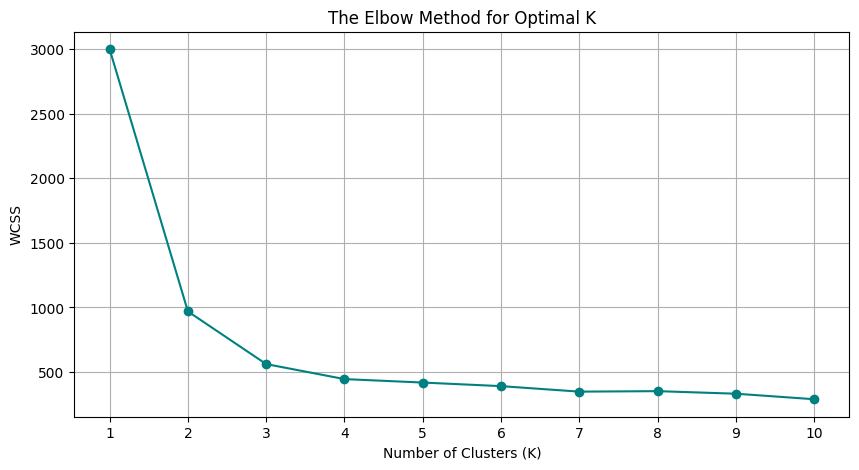

In [ ]:

wcss = []
for i in range(1, 11):
    
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='-', color='teal')
plt.title('The Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

Based on the Elbow Method plot, the optimal number of clusters is K = 3.Justification: > The Elbow Method shows a significant drop in WCSS (Within-Cluster Sum of Squares) from K=1 to K=3. At K=3, there is a clear "elbow" or bend in the graph, after which the reduction in WCSS becomes marginal. This indicates that adding more clusters beyond 3 does not provide significant additional insight into the data structure.

In [7]:

optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
df['cluster'] = kmeans.fit_predict(scaled_features)

centroids = df.groupby('cluster').mean()

print("Cluster Centroids (Average values per segment):")
centroids

Cluster Centroids (Average values per segment):


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
cluster,,,,,,
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,56.769697,89413.333333,2.527273,5530.545455,105.357576,7.515152
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242


Based on the centroid averages, we can segment the customers into three distinct groups:

=>  Cluster 0: "The Frequent Young Budget Shoppers"
    Characteristics: Youngest average age (~25), lowest annual spend (~14.8k), but highest visits per month (~14).
    Business Insight: These are likely students or early-career professionals who visit often but buy small amounts. They are high-engagement but low-transaction value.

=>  Cluster 1: "The At-Risk / Lapsed High-Spenders"
    Characteristics: Highest average age (~57), highest annual spend (~89k), but extremely high "days since last visit" (~105).
    Business Insight: These were your best customers historically, but they haven't visited in over 3 months. They are at a high risk of churning and should be targeted with "We Miss You" re-engagement campaigns.

=>  Cluster 2: "The Mature Mid-Tier Shoppers"
    Characteristics: Mid-age (~40), moderate annual spend (~43k), and the largest basket sizes (~2021).
    Business Insight: These are stable, mature shoppers. They don't visit as often as Cluster 0, but when they do, they buy a lot at once. They represent the "reliable" core of the business.

In [8]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_features)

print(f"Explained Variance Ratio: {pca.explained_variance_ratio_}")

loadings = pd.DataFrame(
    pca.components_.T, 
    columns=['PC1', 'PC2'], 
    index=df.columns[:-1] 
)

print("\nFeature Loadings (PC1 and PC2):")
display(loadings)

Explained Variance Ratio: [0.83560354 0.05568764]

Feature Loadings (PC1 and PC2):


,PC1,PC2
age,0.411569,-0.259432
annual_spend,0.421540,-0.033270
visits_per_month,-0.410399,0.208318
basket_size,0.412012,-0.195402
days_since_last_visit,0.378582,0.911194
num_categories_purchased,0.414017,-0.140479


The first two principal components account for approximately 89.1% of the total variance (PC1: 83.6%, PC2: 5.5%). This means we can visualize the data in 2D while retaining nearly all the original information.

Component Interpretation:

1 PC1 (General Engagement & Value): PC1 has strong positive loadings for age, annual_spend, and basket_size, and a   strong negative loading for visits_per_month. This component essentially separates "High-Value Mature Shoppers"   (positive side) from "Young, Frequent Budget Shoppers" (negative side).

2 PC2 (Recency/Churn Risk): PC2 is heavily dominated by days_since_last_visit (loading of 0.91). This component specifically captures how long it has been since the customer last shopped, acting as a "Recency" axis.

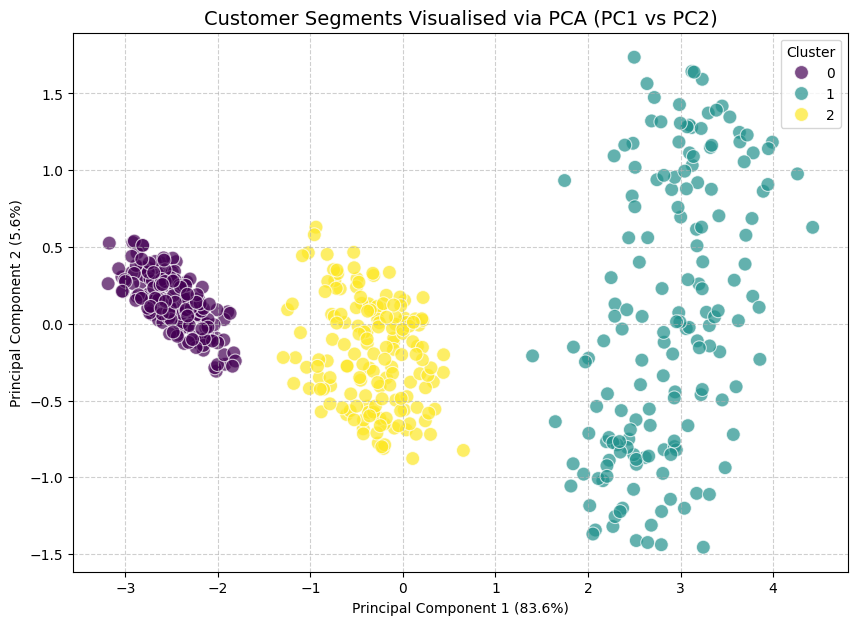

In [9]:

pca_df = pd.DataFrame(data=pca_data, columns=['PC1', 'PC2'])
pca_df['cluster'] = df['cluster']


plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='PC1', 
    y='PC2', 
    hue='cluster', 
    data=pca_df, 
    palette='viridis', 
    s=100, 
    alpha=0.7
)

plt.title('Customer Segments Visualised via PCA (PC1 vs PC2)', fontsize=14)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend(title='Cluster', loc='best')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Visual Analysis:
The scatter plot above visualizes the three customer segments in a 2D space using the first two Principal Components.

Separation: There is a clear, distinct separation between the three clusters along the PC1 (horizontal) axis, which we identified as capturing "General Engagement and Value." This confirms that the K-Means algorithm successfully identified unique groups based on their spending and frequency behaviors.

Cluster 1 (Teal): These points are spread further along the PC2 (vertical) axis, which aligns with our finding that PC2 captures days_since_last_visit. This spread represents the varying levels of "recency" or churn risk within this high-value group.

Conclusion: The high explained variance (89.1%) ensures that this 2D representation is a highly accurate reflection of the true relationships in the 6-dimensional customer data.